In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


C:\Users\91910\AppData\Local\Temp\ipykernel_7572\4111904022.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
d:\GENAI-SERIES\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Load the Documents

loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()

## Splitting - chunks

splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
docs = splitter.split_documents(docs)

# embeddings and vectoe db

embed = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 625.20it/s]


In [4]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [12]:
class Rag_state(BaseModel):
    question:str = Field(description="User question")
    documents:list = []
    context:str = Field(description="Context Data for user question", default="")
    answer:str = Field(description="Final Answer...", default="")


In [13]:
### Nodes
## question -> retrive ->generate -> end

def retrive_node(state:Rag_state) -> Rag_state:
    docs = vector_store.similarity_search(query = state.question)
    state.documents = docs
    return state

def create_context_node(state:Rag_state) -> Rag_state:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state


def generate_node(state:Rag_state) -> Rag_state:
    prompt = f"""
        You are a assistant and provide the answer for user question based on the provided context
        if you don't find the releveant answer,then just say 'I dont know.'.
        Context is: {state.context},
        Question is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state




In [14]:
graph = StateGraph(Rag_state)

graph.add_node("retrive_node",retrive_node)
graph.add_node("create_context_node",create_context_node)
graph.add_node("generate_node",generate_node)

graph.add_edge(START,"retrive_node")
graph.add_edge("retrive_node","create_context_node")
graph.add_edge("create_context_node","generate_node")
graph.add_edge("generate_node",END)

graph = graph.compile()



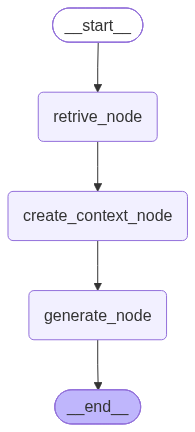

In [15]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [22]:
res = graph.invoke({"question":"Who is the doctor of Patient"})

In [23]:
print(res["answer"])

The doctor of the patient, Ms. Nikita Chudhary, is Dr. Nitin Nahar.
